# 2D Control Matrix Optimization: Time-Wealth Policy

This notebook implements a gradient descent optimizer for a 2D control matrix that responds to both time (age) and wealth.

## Key Features:
- **Bilinear interpolation** across time and wealth dimensions
- **Gradient-based optimization** using PyTorch automatic differentiation
- **Flexible policy representation** with configurable grid resolution
- **Consumption-aware simulation** with inflation and real decline in needs

## Method Overview:
The control matrix C(t, W) defines stock allocation as a function of both:
- **Time (t)**: Years from start of retirement
- **Wealth (W)**: Current portfolio value

We optimize the control matrix nodes, then use bilinear interpolation to get allocations for any (t, W) pair.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
import sys
sys.path.append('..')  # Add Code directory to path

# Import utils package
from utils import (
    CholeskyBootstrapReturns,
    ControlMatrixPolicy,
    FloorCeilingSpending,
    load_historical_returns,
    sample_without_replacement,
    log_consumption_utility,
    smoothness_penalty,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Historical Returns

We'll use the same return data as the age-based optimization.

In [ ]:
# Load historical returns using utils
try:
    yearly_returns, yearly_mean, yearly_cov = load_historical_returns(
        source="sallypy",
        bonds_ticker="BMK0017",
        stocks_ticker="BMK0188"
    )
except:
    # Fallback to CSV if sallypy not available
    print("Loading from CSV...")
    yearly_returns, yearly_mean, yearly_cov = load_historical_returns(
        source="csv",
        csv_path="../WIP/returns.csv"
    )

print(f"Mean annual returns:\n{yearly_mean}")
print(f"\nCovariance matrix:\n{yearly_cov}")

Mean annual returns:
Bonds     0.076926
Stocks    0.112436
dtype: float64

Covariance matrix:
           Bonds    Stocks
Bonds   0.003535  0.000413
Stocks  0.000413  0.041097


## 2. Bilinear Interpolation and Simulation Functions

The control matrix is defined on a discrete grid of time steps and wealth levels. We use the ControlMatrixPolicy class from utils, but need custom simulation logic for the optimization loop.

## 3. Wealth Simulation with 2D Control Matrix

At each time step, we:
1. Calculate consumption based on current wealth
2. Look up stock allocation from control matrix using (time, wealth)
3. Apply returns and update wealth

In [ ]:
def calculate_consumption(wealth: torch.Tensor, 
                         time_step: int,
                         min_consumption_real: float,
                         consumption_rate: float,
                         inflation: float = 0.03,
                         real_decline_rate: float = 0.02) -> torch.Tensor:
    """
    Calculate consumption at a given time step.
    
    Consumption is the maximum of:
    - Minimum consumption (adjusted for inflation and real decline)
    - Percentage of current wealth
    
    Note: This is equivalent to FloorCeilingSpending from utils.spending
    """
    # Adjust min consumption for real decline and inflation
    real_min_consumption = min_consumption_real * ((1 - real_decline_rate) ** time_step)
    nominal_min_consumption = real_min_consumption * ((1 + inflation) ** time_step)
    
    # Percentage-based consumption
    percentage_consumption = wealth * consumption_rate
    
    # Take maximum of the two
    consumption = torch.maximum(
        torch.full_like(wealth, nominal_min_consumption),
        percentage_consumption
    )
    
    # Cannot consume more than available wealth
    consumption = torch.minimum(consumption, wealth)
    
    return consumption


def simulate_wealth_with_control_matrix(
    simulated_returns: torch.Tensor,
    control_matrix: torch.Tensor,
    initial_wealth: float,
    min_consumption_real: float,
    consumption_rate: float,
    max_wealth: float,
    inflation: float = 0.03,
    real_decline_rate: float = 0.02,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Simulate wealth trajectories with 2D control matrix policy.
    
    Uses ControlMatrixPolicy from utils.allocation for allocation lookup.
    
    Parameters
    ----------
    simulated_returns : torch.Tensor
        n x s x 2 tensor of simulated returns [bonds, stocks]
    control_matrix : torch.Tensor
        (n_time_nodes, n_wealth_nodes) tensor of stock allocations
    initial_wealth : float
        Starting wealth
    min_consumption_real : float
        Minimum consumption in real terms at year 0
    consumption_rate : float
        Percentage of wealth to consume
    max_wealth : float
        Maximum wealth bound for control matrix
    inflation : float
        Annual inflation rate
    real_decline_rate : float
        Annual decline in real consumption needs
    
    Returns
    -------
    tuple[torch.Tensor, torch.Tensor]
        (wealth, consumption) - Both as n x (s+1) and n x s tensors
    """
    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    
    # Create allocation policy using utils.allocation.ControlMatrixPolicy
    allocation_policy = ControlMatrixPolicy(
        control_matrix=control_matrix,
        n_timesteps=s,
        max_wealth=max_wealth
    )
    
    wealth_steps = []
    consumption_steps = []
    
    # Initialize wealth
    wealth_t = torch.full((n,), initial_wealth, 
                         dtype=simulated_returns.dtype, 
                         device=simulated_returns.device)
    wealth_steps.append(wealth_t)
    
    for i in range(s):
        # Calculate consumption for this period
        consumption_t = calculate_consumption(
            wealth_t, i, min_consumption_real, consumption_rate, 
            inflation, real_decline_rate
        )
        consumption_steps.append(consumption_t)
        
        # Withdraw consumption
        wealth_after_consumption = wealth_t - consumption_t
        
        # Look up stock allocation using ControlMatrixPolicy from utils
        time_indices = torch.full_like(wealth_t, float(i))
        wealth_clamped = torch.clamp(wealth_after_consumption, 0, max_wealth)
        
        stock_weight = allocation_policy.get_allocation(
            time_idx=time_indices,
            wealth=wealth_clamped
        )
        
        bond_weight = 1 - stock_weight
        
        # Apply returns
        bond_return = simulated_returns[:, i, 0]
        stock_return = simulated_returns[:, i, 1]
        
        portfolio_return = bond_weight * (1 + bond_return) + stock_weight * (1 + stock_return)
        
        # Update wealth
        next_wealth = wealth_after_consumption * portfolio_return
        
        # Ensure non-negative wealth
        next_wealth = torch.maximum(next_wealth, torch.zeros_like(next_wealth))
        
        wealth_steps.append(next_wealth)
        wealth_t = next_wealth
    
    wealth = torch.stack(wealth_steps, dim=1)
    consumption = torch.stack(consumption_steps, dim=1)
    
    return wealth, consumption

## 4. Cost Function: Custom Objectives

We use a combination of objectives:
- `sigmoid_wealth_penalty`: Custom penalty for excessive terminal wealth
- `log_consumption_utility` from utils.objectives (commented out here)
- `smoothness_penalty` from utils.objectives (commented out here)

These custom sigmoid functions provide smooth, differentiable penalty terms for gradient-based optimization.

In [ ]:
# Note: log_consumption_utility is available from utils.objectives
# We keep a local version here for reference, but you can use:
# from utils import log_consumption_utility

def sigmoid_consumption_penalty(
    consumption: torch.Tensor,
    threshold: float = 50000.0,
    steepness: float = 0.0001
) -> torch.Tensor:
    """
    Penalty for consumption above a certain threshold using a sigmoid function.
    
    Custom objective not in utils package - specific to this optimization.
    """
    penalty = -torch.sum(torch.sigmoid(steepness * (consumption - threshold)))
    return penalty

def sigmoid_wealth_penalty(
    wealth: torch.Tensor,
    steepness: float = 0.00001
) -> torch.Tensor:
    """
    Penalty for wealth above a certain threshold using a sigmoid function.
    
    Custom objective not in utils package - specific to this optimization.
    """
    penalty = -torch.sum(torch.sigmoid(steepness * (wealth)))/wealth.numel()
    return penalty

def total_cost(
    consumption: torch.Tensor,
    wealth: torch.Tensor,
    control_matrix: torch.Tensor,
    smoothness_weight: float = 0.00001,
) -> torch.Tensor:
    """
    Calculate total cost: custom sigmoid penalties.
    
    Alternative objectives available in utils.objectives:
    - log_consumption_utility(consumption)
    - smoothness_penalty(control_matrix)
    - terminal_wealth_objective(wealth[:, -1])
    """
    # Main objective: sigmoid wealth penalty
    cost = sigmoid_wealth_penalty(wealth, 1/3000)
    
    # Alternative objectives (commented out):
    # cost += log_consumption_utility(consumption/30000)
    # cost += smoothness_penalty(control_matrix, smoothness_weight)
    
    return cost 

## 5. Optimization Setup

In [297]:
# Simulation parameters
N_SIMULATIONS = 10000   # Number of Monte Carlo simulations
BATCHES = 10            # Number of batches
S_TIMESTEPS = 40        # Number of years to simulate
INITIAL_WEALTH = 500000 # Starting wealth

# Control matrix grid
N_TIME_NODES = 8        # Number of time nodes in control matrix
N_WEALTH_NODES = 30     # Number of wealth nodes in control matrix
MAX_WEALTH = 1500000    # Maximum wealth bound for grid

# Consumption parameters
MIN_CONSUMPTION_REAL = 30000  # Minimum consumption in today's dollars
CONSUMPTION_RATE = 0.00       # 4% of wealth per year
INFLATION = 0.03              # 3% annual inflation
REAL_DECLINE_RATE = 0.02      # 2% decline in real needs per year

# Optimization parameters
SMOOTHNESS_WEIGHT = 0.001     # Penalty for allocation changes
LEARNING_RATE = 0.005          # Initial learning rate
N_ITERATIONS = 2000           # Number of optimization iterations

# PyTorch device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
# Generate simulated returns using CholeskyBootstrapReturns from utils
returns_generator = CholeskyBootstrapReturns(yearly_mean, yearly_cov)
mc_returns = torch.tensor(
    returns_generator.generate(
        n_simulations=N_SIMULATIONS*BATCHES,
        n_timesteps=S_TIMESTEPS
    ),
    dtype=torch.float32,
    device=DEVICE
)

print(f"Simulated returns shape: {mc_returns.shape}")
print(f"Mean bond return: {mc_returns[:, :, 0].mean():.4f}")
print(f"Mean stock return: {mc_returns[:, :, 1].mean():.4f}")

Simulated returns shape: torch.Size([100000, 40, 2])
Mean bond return: 0.0769
Mean stock return: 0.1122


In [299]:
# Initialize control matrix
# Start with a simple age-based decline: high stocks early, declining over time
# And wealth-responsive: higher stocks for higher wealth (more risk capacity)

time_gradient = np.linspace(0, 0, N_TIME_NODES)
wealth_gradient = np.linspace(0, 0, N_WEALTH_NODES)

# Create initial matrix as outer product (time effect × wealth effect)
initial_matrix = np.outer(time_gradient, wealth_gradient)

control_matrix = torch.tensor(
    initial_matrix,
    dtype=torch.float32,
    requires_grad=True,
    device=DEVICE
)

print(f"Control matrix shape: {control_matrix.shape}")
print(f"Initial control matrix:")
print(control_matrix.detach().cpu().numpy())

Control matrix shape: torch.Size([8, 30])
Initial control matrix:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]


## 6. Gradient Descent Optimization Loop

In [ ]:
# Setup optimizer
optimizer = torch.optim.Adam([control_matrix], lr=LEARNING_RATE)

# Track optimization progress
cost_history = []
control_matrix_history = []
lr_history = []

# Adaptive learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50
)

print("Starting optimization...\n")

# Note: sample_without_replacement is imported from utils.helpers

for iteration in range(N_ITERATIONS):
    optimizer.zero_grad()
    
    # Sample returns for this iteration
    sampled_returns = sample_without_replacement(mc_returns, N_SIMULATIONS)
    
    # Simulate wealth and consumption
    wealth, consumption = simulate_wealth_with_control_matrix(
        simulated_returns=sampled_returns,
        control_matrix=control_matrix,
        initial_wealth=INITIAL_WEALTH,
        min_consumption_real=MIN_CONSUMPTION_REAL,
        consumption_rate=CONSUMPTION_RATE,
        max_wealth=MAX_WEALTH,
        inflation=INFLATION,
        real_decline_rate=REAL_DECLINE_RATE,
    )
    
    # Calculate cost
    cost = total_cost(
        consumption=consumption,
        wealth=wealth,
        control_matrix=control_matrix,
        smoothness_weight=SMOOTHNESS_WEIGHT,
    )
    
    # Backward pass
    cost.backward()
    
    # Gradient clipping to prevent explosions
    torch.nn.utils.clip_grad_norm_([control_matrix], max_norm=1.0)
    
    # Update weights
    optimizer.step()
    
    # Clamp control matrix to [0, 1]
    with torch.no_grad():
        control_matrix.clamp_(0.0, 1.0)
    
    # Update learning rate
    scheduler.step(cost)
    
    # Track metrics
    cost_history.append(cost.item())
    lr_history.append(optimizer.param_groups[0]['lr'])
    
    # Save snapshots periodically
    if iteration % 50 == 0:
        control_matrix_history.append(control_matrix.detach().cpu().numpy().copy())
    
    # Print progress
    if (iteration + 1) % 100 == 0:
        print(f"Iteration {iteration + 1}/{N_ITERATIONS}")
        print(f"  Cost: {cost.item():.6f}")
        print(f"  Mean log consumption: {-cost.item():.6f}")
        print(f"  Mean consumption: ${consumption.mean().item():,.0f}")
        print(f"  Mean terminal wealth: ${wealth[:, -1].mean().item():,.0f}")
        print(f"  Bankruptcy rate: {(wealth[:, -1] == 0).sum().item() / N_SIMULATIONS:.2%}")
        print(f"  Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
        print()

print("\nOptimization complete!")

Starting optimization...

Iteration 100/2000
  Cost: -0.989264
  Mean log consumption: 0.989264
  Mean consumption: $35,375
  Mean terminal wealth: $1,627,910
  Bankruptcy rate: 9.96%
  Learning rate: 0.005000

Iteration 200/2000
  Cost: -0.990826
  Mean log consumption: 0.990826
  Mean consumption: $35,499
  Mean terminal wealth: $1,659,044
  Bankruptcy rate: 8.29%
  Learning rate: 0.005000

Iteration 300/2000
  Cost: -0.991736
  Mean log consumption: 0.991736
  Mean consumption: $35,571
  Mean terminal wealth: $1,676,321
  Bankruptcy rate: 7.20%
  Learning rate: 0.005000

Iteration 400/2000
  Cost: -0.991605
  Mean log consumption: 0.991605
  Mean consumption: $35,561
  Mean terminal wealth: $1,700,853
  Bankruptcy rate: 7.22%
  Learning rate: 0.002500

Iteration 500/2000
  Cost: -0.991871
  Mean log consumption: 0.991871
  Mean consumption: $35,582
  Mean terminal wealth: $1,707,189
  Bankruptcy rate: 6.95%
  Learning rate: 0.002500

Iteration 600/2000
  Cost: -0.991246
  Mean log c

KeyboardInterrupt: 

## 7. Results Visualization

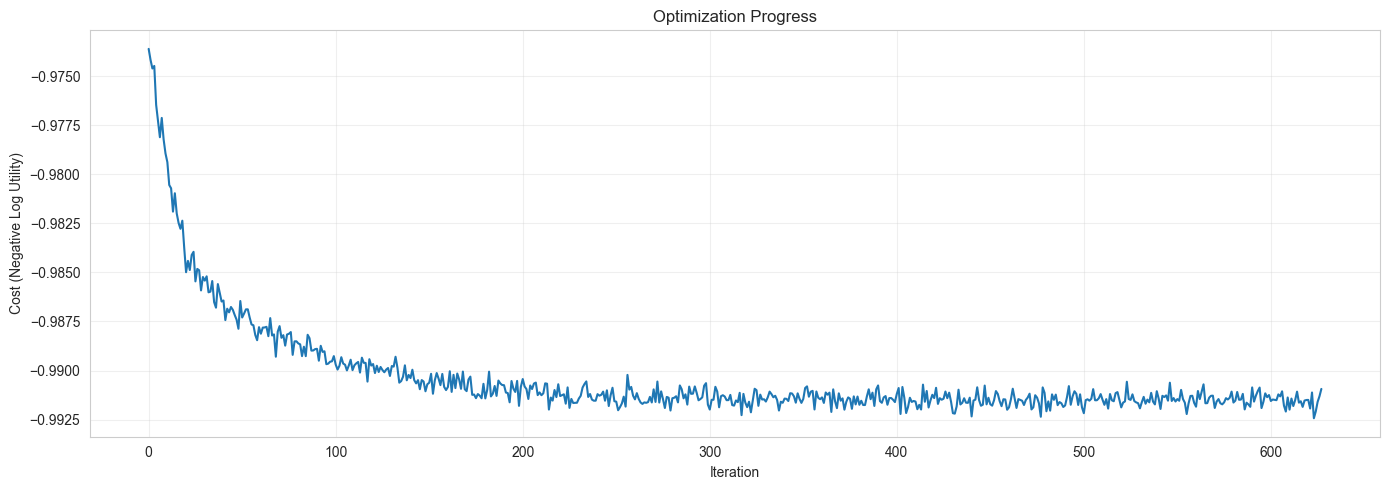

In [301]:
# Plot optimization progress
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(cost_history)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost (Negative Log Utility)')
ax.set_title('Optimization Progress')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

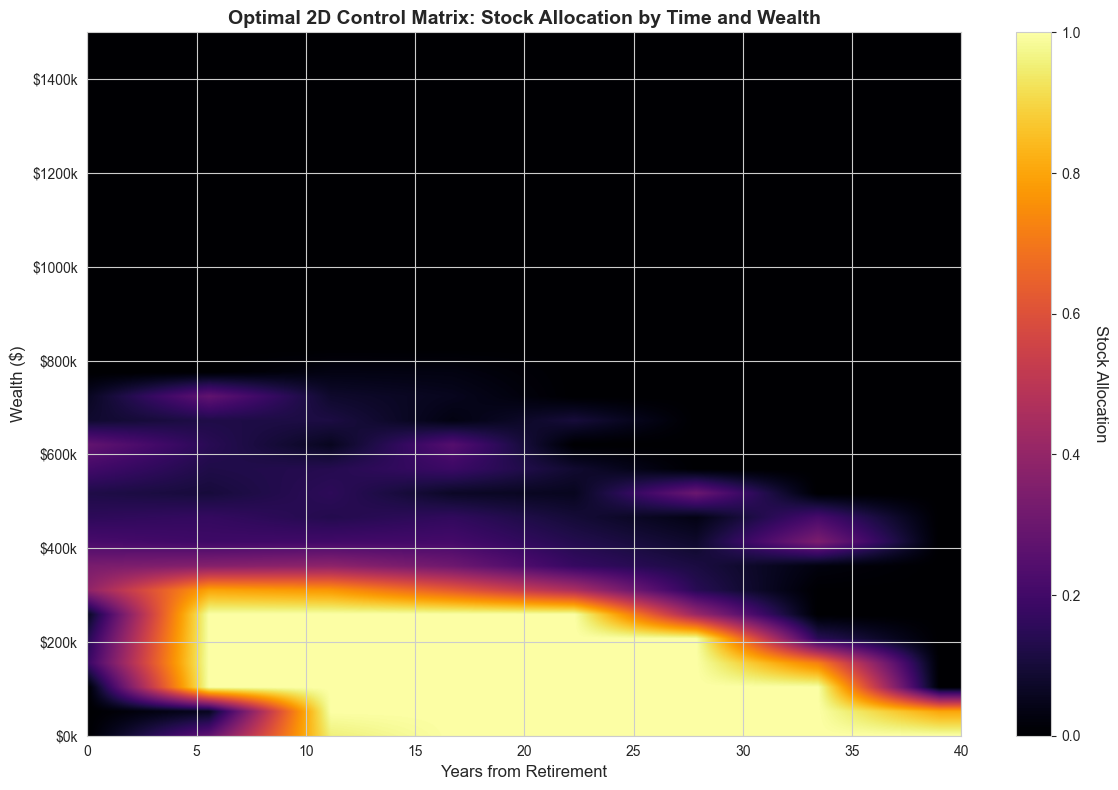


Optimal Control Matrix:
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.77467406e-01
  1.34156182e-01 5.82009703e-02 3.87131065e-01 3.34156007e-01
  2.15562597e-01 1.55188650e-01 1.22909881e-01 2.03302354e-01
  2.80587584e-01 8.23413581e-02 5.86430207e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [2.68205017e-01 5.57590201e-02 1.00000000e+00 1.00000000e+00
  1.00000000e+00 1.00000000e+00 8.00532937e-01 3.64531547e-01
  1.91942468e-01 1.70887038e-01 1.03039466e-01 1.23978794e-01
  1.45093918e-01 1.23147734e-01 2.76783317e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [9.56611812e-01 1.00000000e+00 1.0000000

In [ ]:
# Plot optimal control matrix as heatmap
final_matrix = control_matrix.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 8))

# Create fine grid for smooth visualization
time_grid = np.linspace(0, S_TIMESTEPS, 1000)
wealth_grid = np.linspace(0, MAX_WEALTH, 1000)
T_mesh, W_mesh = np.meshgrid(time_grid, wealth_grid)

# Use ControlMatrixPolicy for interpolation
allocation_policy = ControlMatrixPolicy(
    control_matrix=control_matrix,
    n_timesteps=S_TIMESTEPS,
    max_wealth=MAX_WEALTH
)

interpolated_matrix = allocation_policy.get_allocation(
    time_idx=torch.tensor(T_mesh.flatten(), device=DEVICE),
    wealth=torch.tensor(W_mesh.flatten(), device=DEVICE)
).cpu().detach().numpy().reshape(T_mesh.shape)

im = ax.imshow(
    interpolated_matrix,
    aspect='auto',
    extent=[0, S_TIMESTEPS, 0, MAX_WEALTH],
    origin='lower',
    cmap='inferno',
    vmin=0,
    vmax=1
)

# Labels and colorbar
ax.set_xlabel('Years from Retirement', fontsize=12)
ax.set_ylabel('Wealth ($)', fontsize=12)
ax.set_title('Optimal 2D Control Matrix: Stock Allocation by Time and Wealth', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Stock Allocation', rotation=270, labelpad=20, fontsize=12)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

print("\nOptimal Control Matrix:")
print(final_matrix)

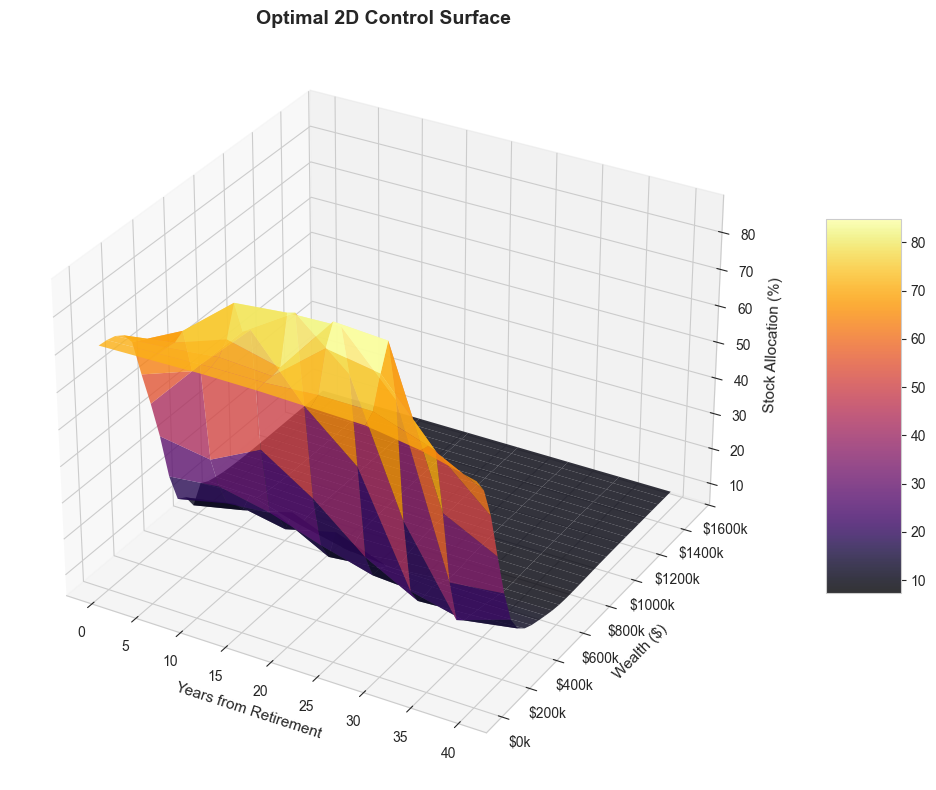

In [281]:
# Plot 3D surface
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid for surface plot
time_grid = np.linspace(0, S_TIMESTEPS, N_TIME_NODES)
wealth_grid = np.linspace(0, MAX_WEALTH, N_WEALTH_NODES)
T_mesh, W_mesh = np.meshgrid(time_grid, wealth_grid)

# Plot surface
surf = ax.plot_surface(
    T_mesh, W_mesh, final_matrix.T * 100,
    cmap='inferno',
    alpha=0.8,
    edgecolor='none'
)

ax.set_xlabel('Years from Retirement', fontsize=11)
ax.set_ylabel('Wealth ($)', fontsize=11)
ax.set_zlabel('Stock Allocation (%)', fontsize=11)
ax.set_title('Optimal 2D Control Surface', fontsize=14, fontweight='bold')

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

## 8. Final Simulation and Analysis

In [251]:
# Run final simulation with optimal control matrix
with torch.no_grad():
    wealth_final, consumption_final = simulate_wealth_with_control_matrix(
        simulated_returns=mc_returns,
        control_matrix=control_matrix,
        initial_wealth=INITIAL_WEALTH,
        min_consumption_real=MIN_CONSUMPTION_REAL,
        consumption_rate=CONSUMPTION_RATE,
        max_wealth=MAX_WEALTH,
        inflation=INFLATION,
        real_decline_rate=REAL_DECLINE_RATE,
    )
    
    wealth_final_np = wealth_final.cpu().numpy()
    consumption_final_np = consumption_final.cpu().numpy()

ages = np.arange(65, 65 + S_TIMESTEPS)

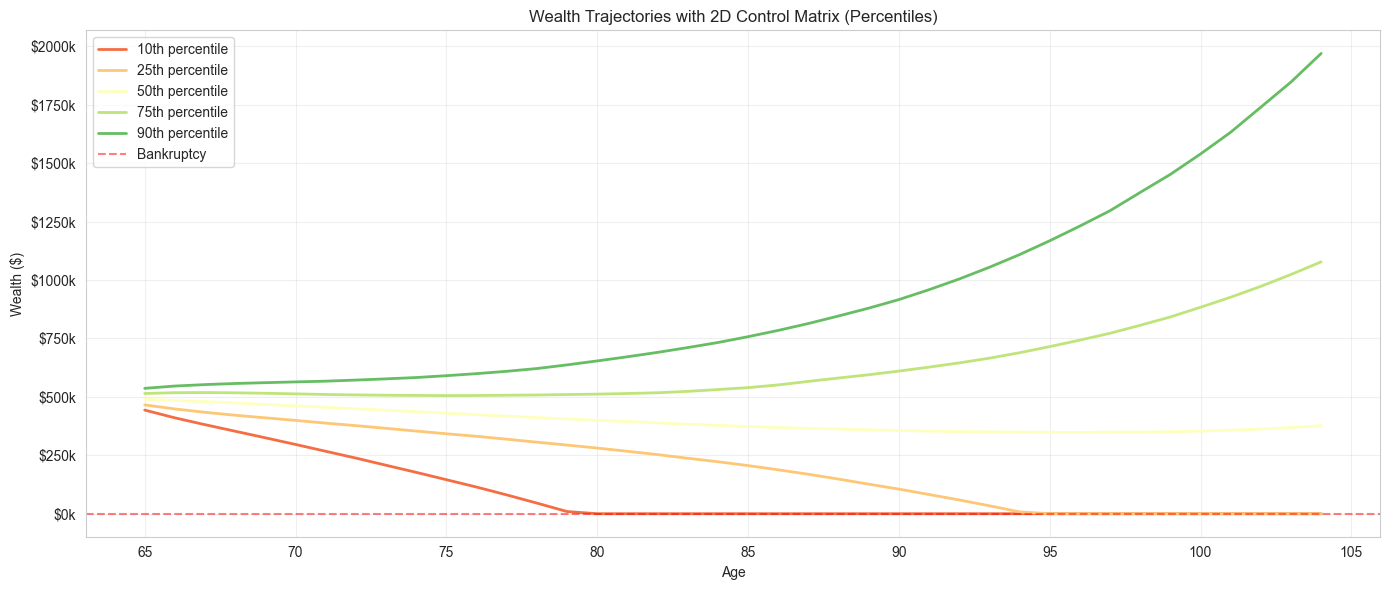

In [252]:
# Plot wealth trajectories
plt.figure(figsize=(14, 6))

percentiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(percentiles)))

for i, p in enumerate(percentiles):
    plt.plot(ages, np.percentile(wealth_final_np[:, 1:], p, axis=0), 
             label=f'{p}th percentile', linewidth=2, color=colors[i])

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Bankruptcy')
plt.xlabel('Age')
plt.ylabel('Wealth ($)')
plt.title('Wealth Trajectories with 2D Control Matrix (Percentiles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

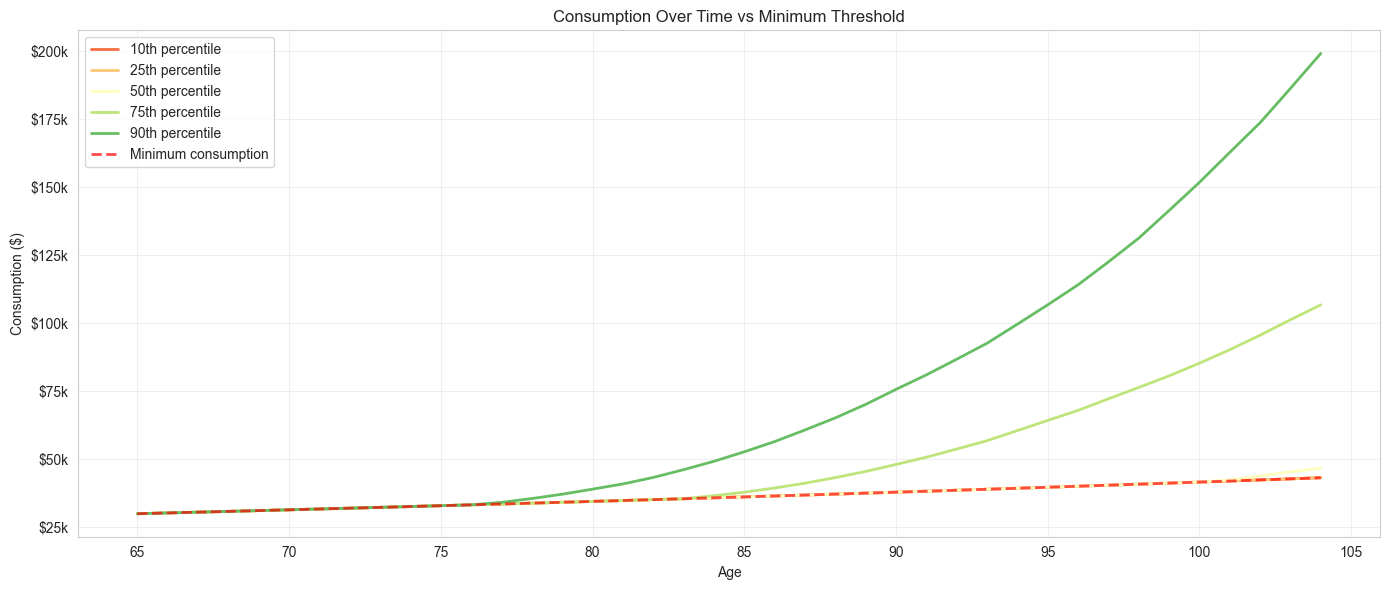

In [232]:
# Plot consumption vs minimum threshold
plt.figure(figsize=(14, 6))

# Calculate minimum consumption nominal values over time
min_consumption_nominal = np.array([
    MIN_CONSUMPTION_REAL * ((1 - REAL_DECLINE_RATE) ** t) * ((1 + INFLATION) ** t)
    for t in range(S_TIMESTEPS)
])

# Plot consumption percentiles
for i, p in enumerate([10, 25, 50, 75, 90]):
    plt.plot(ages, np.percentile(consumption_final_np, p, axis=0),
             label=f'{p}th percentile', linewidth=2, color=colors[i])

# Plot minimum consumption threshold
plt.plot(ages, min_consumption_nominal, 'r--', linewidth=2, label='Minimum consumption', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Consumption ($)')
plt.title('Consumption Over Time vs Minimum Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

In [156]:
# Summary statistics
print("=" * 60)
print("2D CONTROL MATRIX OPTIMIZATION RESULTS")
print("=" * 60)

print(f"\nControl Matrix Configuration:")
print(f"  Time nodes: {N_TIME_NODES}")
print(f"  Wealth nodes: {N_WEALTH_NODES}")
print(f"  Max wealth bound: ${MAX_WEALTH:,.0f}")
print(f"  Interpolation: Bilinear")

print(f"\nInitial Parameters:")
print(f"  Initial wealth: ${INITIAL_WEALTH:,.0f}")
print(f"  Min consumption (real, year 0): ${MIN_CONSUMPTION_REAL:,.0f}")
print(f"  Consumption rate: {CONSUMPTION_RATE:.1%}")
print(f"  Simulation horizon: {S_TIMESTEPS} years")
print(f"  Number of simulations: {N_SIMULATIONS * BATCHES:,}")

bankruptcy_rate = (wealth_final[:, -1] == 0).sum().item() / (N_SIMULATIONS * BATCHES)
median_terminal_wealth = np.median(wealth_final_np[:, -1])
mean_terminal_wealth = wealth_final_np[:, -1].mean()

print(f"\nOutcome Statistics:")
print(f"  Mean log consumption: {np.log(consumption_final_np + 1e-8).mean():.4f}")
print(f"  Mean consumption: ${consumption_final_np.mean():,.0f}")
print(f"  Median consumption: ${np.median(consumption_final_np):,.0f}")
print(f"  Bankruptcy rate: {bankruptcy_rate:.2%}")
print(f"  Mean terminal wealth: ${mean_terminal_wealth:,.0f}")
print(f"  Median terminal wealth: ${median_terminal_wealth:,.0f}")
print(f"  10th percentile terminal wealth: ${np.percentile(wealth_final_np[:, -1], 10):,.0f}")
print(f"  90th percentile terminal wealth: ${np.percentile(wealth_final_np[:, -1], 90):,.0f}")

print("\n" + "=" * 60)

2D CONTROL MATRIX OPTIMIZATION RESULTS

Control Matrix Configuration:
  Time nodes: 10
  Wealth nodes: 15
  Max wealth bound: $1,500,000
  Interpolation: Bilinear

Initial Parameters:
  Initial wealth: $500,000
  Min consumption (real, year 0): $30,000
  Consumption rate: 4.0%
  Simulation horizon: 40 years
  Number of simulations: 100,000

Outcome Statistics:
  Mean log consumption: 10.1289
  Mean consumption: $44,905
  Median consumption: $36,513
  Bankruptcy rate: 6.06%
  Mean terminal wealth: $1,858,154
  Median terminal wealth: $1,442,465
  10th percentile terminal wealth: $265,346
  90th percentile terminal wealth: $3,815,942



## 9. Save Results

In [157]:
# Save control matrix
np.save('control_matrix_optimal.npy', final_matrix)
print("Saved optimal control matrix to 'control_matrix_optimal.npy'")

# Save summary statistics
summary_stats = pd.DataFrame({
    'Metric': [
        'Mean Terminal Wealth',
        'Median Terminal Wealth',
        '10th Percentile Terminal Wealth',
        '90th Percentile Terminal Wealth',
        'Bankruptcy Rate',
        'Mean Consumption',
        'Mean Log Consumption'
    ],
    'Value': [
        mean_terminal_wealth,
        median_terminal_wealth,
        np.percentile(wealth_final_np[:, -1], 10),
        np.percentile(wealth_final_np[:, -1], 90),
        bankruptcy_rate,
        consumption_final_np.mean(),
        np.log(consumption_final_np + 1e-8).mean()
    ]
})

summary_stats.to_csv('control_matrix_results.csv', index=False)
print("Saved summary statistics to 'control_matrix_results.csv'")

Saved optimal control matrix to 'control_matrix_optimal.npy'
Saved summary statistics to 'control_matrix_results.csv'
